Demographics
====

Demographic type plots

In [1]:
import os

%load_ext autoreload
%autoreload 2

img_dir = "outputs/imgs/demographics/"
if not os.path.exists(img_dir):
    os.makedirs(img_dir)

In [2]:
"""
Read the data

"""

import pandas as pd

from analysis_utils import read

df = read.survey_info()

# Find only the people who were asked to take part in the smartwatch study
keep = ~pd.isna(df["smart1_7to9"]) | ~pd.isna(df["smart1_10to17"])
df = df[keep]

len(df)

/home/mh19137/seaco_smartwatch_paper/analysis_utils/read.py:137: DtypeWarning: Columns (17,25,26,52,197,198,200,201,209,210,212,213,216,218,219,222,225,227,228,230,231,233,234,236,237,239,240,243,246,248,249,252,254,255,257,258,261,263,264,267,269,270,272,273,276,279,281,284,291,293,294,296,297,300,302,303,305,306,309,311,312,314,315,317,318,321,324,327,330,344,351,352,354,355,360,361,362,363,364,369,370,371,372,373,378,379,380,381,382,387,390,391,396,397,398,399,400,406,407,415,425,432,434,435,436,446,456,486,499,504,506,512,513,549) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


87

,count,sex
respondent_sex,,
2.0,54,Female
1.0,33,Male


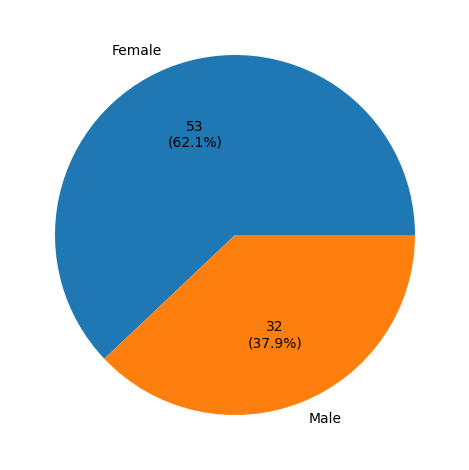

In [3]:
"""
Sex pie chart

"""

import matplotlib.pyplot as plt

sexes = pd.DataFrame(df["respondent_sex"].value_counts())

# 1 for Male 2 for Female
sexes["sex"] = ["Female" if i - 1 else "Male" for i in sexes.index]


def autopct(val):
    return f"{int(val * len(df) / 100)}\n({val:.1f}%)"


fig, axis = plt.subplots()
axis.pie(
    sexes["count"],
    labels=sexes["sex"],
    autopct=autopct,
)
fig.tight_layout()
fig.savefig(f"{img_dir}/sex_pie.png")

sexes

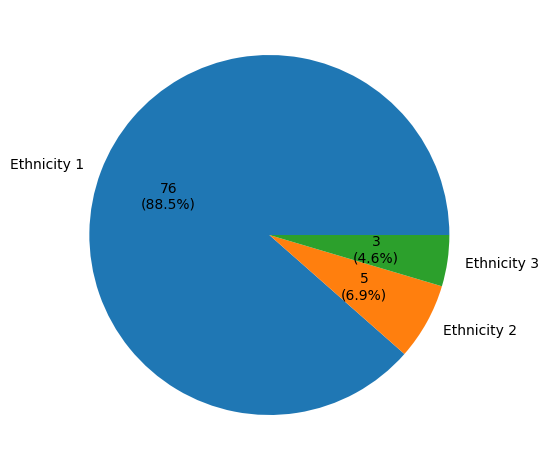

In [4]:
"""
Ethnicity pie chart

"""

ethnicities = df["respondent_ethnicity"].value_counts()

fig, axis = plt.subplots()
axis.pie(
    ethnicities,
    labels=[f"Ethnicity {int(i)}" for i in ethnicities.index],
    autopct=autopct,
)
fig.tight_layout()
fig.savefig(f"{img_dir}/ethnicity_pie.png")

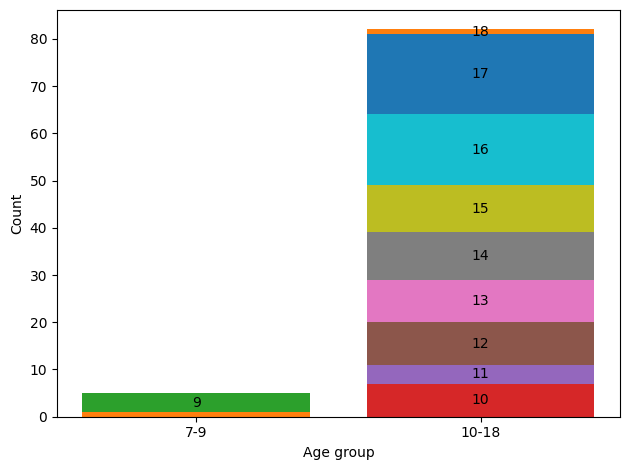

In [5]:
"""
Age histogram

"""

# Stacked bar plot
fig, ax = plt.subplots()

bottom = 0
for age in range(7, 10):
    count = (df["age_dob"] == age).sum()
    ax.bar(0, count, bottom=bottom)
    if count > 2:
        ax.text(0, bottom + count / 2, age, ha="center", va="center")
    bottom += count

bottom = 0
for age in range(10, 19):
    count = (df["age_dob"] == age).sum()
    ax.bar(1, count, bottom=bottom)
    ax.text(1, bottom + count / 2, age, ha="center", va="center")
    bottom += count

ax.set_xticks((0, 1), ("7-9", "10-18"))

ax.set_ylabel("Count")
ax.set_xlabel("Age group")

fig.tight_layout()
fig.savefig(f"{img_dir}/age_hist.png")

In [6]:
"""
Number of participants per date with Ramadan indicated

"""

# Find when each participant started the study
feasibility = read.smartwatch_feasibility()
date_df = df.merge(
    feasibility[["actualdateofdistribution1st", "residents_id"]], on="residents_id"
)

# Keep only people who took part in the smartwatch study
keep = (date_df["smart1_7to9"] == 1) | (date_df["smart1_10to17"] == 1)
date_df = date_df[keep]


# Find the overall start and end dates
study_length = pd.Timedelta(days=8)
first, last = (
    date_df["actualdateofdistribution1st"].min().date(),
    date_df["actualdateofdistribution1st"].max().date() + study_length,
)
days = pd.date_range(first, last, freq="1d")

n_active_participants = []
for day in days:
    n_active = 0
    # Check how many participants were active (start date within 7 days of this day)
    for _, row in date_df.iterrows():
        end_date = row["actualdateofdistribution1st"] + study_length
        if row["actualdateofdistribution1st"] <= day < end_date:
            n_active += 1

    n_active_participants.append(n_active)

# Check that all the entries sum up to 83 (participants) * days
assert sum(n_active_participants) == 83 * study_length.days

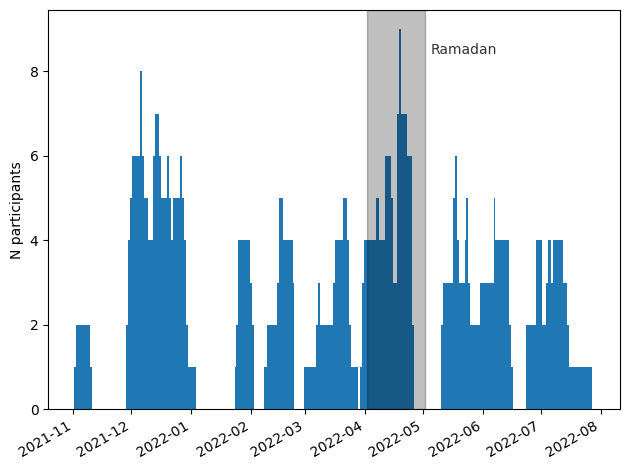

In [39]:
"""
Plot the number of participants per day as a histogram

"""

from analysis_utils import clean, plotting

# Convert the days to bins centred on each day
bins = days - pd.Timedelta(hours=12)
bins = bins.append(pd.DatetimeIndex([pd.to_datetime(last) + pd.Timedelta(hours=12)]))

fig, axis = plt.subplots()

axis.stairs(n_active_participants, bins, fill=True)

plotting.shade_ramadan(axis)
_, ramadan = clean.ramadan_2022()
axis.text(
    ramadan + pd.Timedelta(days=3),
    8.5,
    "Ramadan",
    ha="left",
    va="center",
    color="black",
    alpha=0.8,
)

axis.set_ylabel("N participants")

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(f"{img_dir}/participants_per_day.png")